# Harringtonine fixed-ki elongation-rate optimization

Simulation and optimization settings are defined in the parameter cell below.


In [1]:
from pathlib import Path
import hashlib
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from joblib import Parallel, delayed
from numba import njit

from tasep_models import (TASEP_SSA,calculate_codon_elongation_rates,create_probe_vector,read_sequence,tag_dict,)

main_dir = Path("/Users/nzlab-la/Desktop/utag_paper")
figure_7_dir = main_dir / "notebooks" / "Figure_7"

figures_folder = figure_7_dir / "figures"
raw_data_folder = figure_7_dir / "raw_data"
optimization_tables_folder = figure_7_dir / "optimization_tables"

for folder in (figures_folder, raw_data_folder, optimization_tables_folder):
    folder.mkdir(parents=True, exist_ok=True)

In [2]:
# Experimental and simulation parameters
harringtonine_frame = 5
max_frame = 30
drug_entry_delay_seconds = 30
number_repetitions = 200
burnin_time = 2000
step_size_in_sec = 1
inhibition_effectiveness = 95
fixed_ki = 0.03
response_threshold = 0.3
REPRODUCIBLE_RANDOM_SEED = 42
REPRODUCIBLE_N_JOBS = -1

# Optimization grid
ke_grid_min = 1.0
ke_grid_max = 8.0
ke_grid_step = 0.1

# Bootstrap settings
HT_BOOTSTRAP_REPLICATES = 2000
HT_BOOTSTRAP_INTERVAL_LEVEL = 0.90
cost_epsilon = 1e-6
samples_per_minute = round(60 / step_size_in_sec)

In [3]:
@njit
def numba_seed(seed):
    np.random.seed(seed)

def stable_seed(*parts):
    """Create a deterministic uint32 seed from notebook/script-stable values."""
    key = "|".join(str(part) for part in parts).encode("utf-8")
    return int.from_bytes(hashlib.blake2b(key, digest_size=4).digest(), "little")

def seed_all_rngs(seed):
    """Seed Python, NumPy, and Numba RNGs from the same deterministic seed."""
    seed = int(seed) % (2**32 - 1)
    random.seed(seed)
    np.random.seed(seed)
    numba_seed(seed)
    return seed

def _build_tasep_rate_vector(ki, ke, gene_length, pause_location=None, pause_elongation_rate=None):
    if isinstance(ke, (int, float)):
        k_elongation = np.full(gene_length - 2, ke, dtype=np.float64)
    else:
        k_elongation = np.asarray(ke, dtype=np.float64)
    k_termination = k_elongation[-1]
    k_full = np.concatenate(([ki], k_elongation, [k_termination])).astype(np.float64)
    if pause_location is not None and pause_elongation_rate is not None:
        if 0 <= pause_location < gene_length:
            k_full[pause_location] = pause_elongation_rate
        else:
            raise ValueError("pause_location must be within the range of gene_length.")
    return k_full

def _run_seeded_fast_tasep(args):
    seed, tasep_args = args
    seed_all_rngs(seed)
    return TASEP_SSA(*tasep_args)

def simulate_TASEP_SSA_seeded_fast(ki, ke, gene_length, t_max, time_interval_in_seconds=1,
                                   number_repetitions=1, first_probe_position_vector=None,
                                   timePerturbationApplication=0, evaluatingInhibitor=0,
                                   evaluatingFRAP=0, n_jobs=-1, burnin_time=0,
                                   inhibitor_effectiveness=0, constant_elongation_rate=None,
                                   pause_location=None, pause_elongation_rate=None,
                                   fast_output=True, batch_size='auto',
                                   random_seed=REPRODUCIBLE_RANDOM_SEED,
                                   seed_context="tasep"):
    """Deterministic parallel fast-output SSA wrapper.

    Each repetition gets its own stable seed inside the joblib worker, so results are
    independent of worker count and process scheduling.
    """
    if not fast_output:
        raise ValueError("simulate_TASEP_SSA_seeded_fast supports fast_output=True only.")

    if burnin_time > 0:
        timePerturbationApplication = (timePerturbationApplication or 0) + burnin_time
        t_max += burnin_time

    t_array = np.arange(0, t_max, time_interval_in_seconds, dtype=np.float64)
    k_full = _build_tasep_rate_vector(ki, ke, gene_length, pause_location, pause_elongation_rate)
    if first_probe_position_vector is None:
        first_probe_position_vector = np.empty(0, dtype=np.float64)
    else:
        first_probe_position_vector = np.asarray(first_probe_position_vector, dtype=np.float64)

    constant_rate = constant_elongation_rate if constant_elongation_rate is not None else -1.0
    tasep_args = (k_full, t_array, timePerturbationApplication, int(evaluatingInhibitor),
                  int(evaluatingFRAP), inhibitor_effectiveness, constant_rate,
                  True, first_probe_position_vector)
    args_list = [
        (stable_seed(random_seed, seed_context, rep), tasep_args)
        for rep in range(number_repetitions)
    ]

    list_first_signal = Parallel(n_jobs=n_jobs, batch_size=batch_size)(
        delayed(_run_seeded_fast_tasep)(args) for args in args_list
    )
    matrix_intensity_first_signal_RT = np.asarray(list_first_signal)

    if burnin_time > 0:
        idx_burnin = int(burnin_time / time_interval_in_seconds)
        matrix_intensity_first_signal_RT = matrix_intensity_first_signal_RT[:, idx_burnin:]

    return (None, None, matrix_intensity_first_signal_RT, None)

In [4]:
acf_results_folder = main_dir / 'optimization' / 'results_ACF'
results_HT_data = Path('/Volumes/LaCie/UTag_paper_data/Harringtonine')
if not results_HT_data.is_dir():
    raise FileNotFoundError(f'Required LaCie HT source is unavailable: {results_HT_data}')
print(f'Using required HT source root: {results_HT_data}')

HT_DATASET_DIRECTORIES = {
    'utag': results_HT_data / 'UTag' / 'HT_Analysis_GUI',
    'utag_c_free': results_HT_data / 'UTag_CF' / 'HT_Analysis_GUI',
    'suntag': results_HT_data / 'SunTag' / 'HT_Analysis_GUI',
    'alfatag': results_HT_data / 'AlfaTag' / 'HT_Analysis_GUI',
}
HT_PLOT_NAMES = {
    'utag': 'UTag',
    'utag_c_free': 'UTag_C_Free',
    'suntag': 'SunTag',
    'alfatag': 'AlfaTag',
}
HT_PUBLICATION_INFO = {
    'utag': ('Figure_7J_UTag_HT', 'Figure_7J_UTag_HT_curves.csv'),
    'utag_c_free': ('Figure_7K_UTag_DeltaCys_HT', 'Figure_7K_UTag_DeltaCys_HT_curves.csv'),
    'suntag': ('Figure_7L_SunTag_HT', 'Figure_7L_SunTag_HT_curves.csv'),
    'alfatag': ('Figure_7M_ALFA_tag_HT', 'Figure_7M_ALFA_tag_HT_curves.csv'),
}
for dataset_name, dataset_directory in HT_DATASET_DIRECTORIES.items():
    if not dataset_directory.is_dir():
        raise FileNotFoundError(f'Missing HT directory for {dataset_name}: {dataset_directory}')

def load_real_tracking_dataframes(results_dir):
    """Load exactly one real tracking CSV from every results_* directory."""
    subfolders = sorted(
        [folder for folder in results_dir.iterdir() if folder.is_dir() and folder.name.startswith('results_')],
        key=lambda folder: folder.name,
    )
    list_dataframes = []
    for subfolder in subfolders:
        files = sorted([
            file for file in subfolder.iterdir()
            if file.is_file()
            and file.name.startswith('tracking_')
            and not file.name.startswith('._')
            and file.suffix.lower() == '.csv'
        ], key=lambda file: file.name)
        if len(files) != 1:
            raise ValueError(f'Expected exactly one real tracking CSV in {subfolder}; found {len(files)}')
        list_dataframes.append(pd.read_csv(files[0]))
    if not list_dataframes:
        raise ValueError(f'No results_* tracking data found in {results_dir}')
    return list_dataframes



Using required HT source root: /Volumes/LaCie/UTag_paper_data/Harringtonine


In [5]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.5,
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.labelcolor': 'black',
    'text.color': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.edgecolor': 'black',
})

In [6]:
def model_and_data_selection(dataset):
    tag_name, dna_filename = {
        'utag': ('U', 'pNZ208(pUB-24xUTagFullLength-KDM5B-MS2).dna'),
        'utag_c_free': ('U', 'pNZ208(pUB-24xUTagFullLength-KDM5B-MS2).dna'),
        'suntag': ('SUN', 'pNZ266(pUB-24xGCN4-KDM5B-MS2).dna'),
        'alfatag': ('ALFA', 'pNZ267 (pUB-24xALFAtag-KDM5B-MS2).dna'),
    }[dataset]
    dna_file_path = main_dir / 'gene_sequences' / 'utag_project' / dna_filename
    protein, rna, _, indexes_tags, *_ = read_sequence(
        seq=dna_file_path, min_protein_length=50, TAG=[tag_dict[tag_name]]
    )
    gene_length = len(protein) + 1
    first_probe_position_vector = create_probe_vector(indexes_tags[0], gene_length)
    return rna, first_probe_position_vector, gene_length

In [7]:
def calculate_intensity(particle_counts_per_frame, sum_intensities_per_frame, harringtonine_frame):
    """Calculate the normalized HT trajectory used in the analysis."""
    pre_counts = particle_counts_per_frame[:harringtonine_frame]
    pre_intensities = sum_intensities_per_frame[:harringtonine_frame]
    intensity_before_treatment = np.divide(
        pre_intensities,
        pre_counts,
        out=np.zeros_like(pre_intensities, dtype=float),
        where=pre_counts != 0,
    )

    average_particles_before_treatment = pre_counts.mean()
    post_intensities = sum_intensities_per_frame[harringtonine_frame:]
    if average_particles_before_treatment == 0:
        intensity_after_treatment = np.zeros_like(post_intensities, dtype=float)
    else:
        intensity_after_treatment = post_intensities / average_particles_before_treatment

    intensity = np.concatenate([intensity_before_treatment, intensity_after_treatment])
    baseline = intensity_before_treatment.mean()
    return intensity / baseline if baseline else np.zeros_like(intensity)

In [8]:
def evaluate_harringtonine_ke_optimization(processed_data):
    """Evaluate the fixed-ki HT cost over a discrete ke grid."""
    if processed_data not in HT_DATASET_DIRECTORIES:
        raise ValueError(f'Unknown HT dataset: {processed_data}')
    results_dir = HT_DATASET_DIRECTORIES[processed_data]
    plot_name = HT_PLOT_NAMES[processed_data]
    
    print(f'\nOptimizing HT elongation rate for {plot_name}')
    list_dataframes = load_real_tracking_dataframes(results_dir)
    
    full_frames = np.arange(0, max_frame) 
    intensities_normalized = np.zeros((len(list_dataframes), len(full_frames)))
    
    for i, df in enumerate(list_dataframes):
        particle_counts_per_frame = df.groupby('frame')['particle'].nunique()
        sum_intensities_per_frame = df.groupby('frame')['spot_int_ch_0'].sum()
        particle_counts_per_frame = particle_counts_per_frame.reindex(full_frames, fill_value=0).values
        sum_intensities_per_frame = sum_intensities_per_frame.reindex(full_frames, fill_value=0).values
        
        intensities_normalized[i] = calculate_intensity(
            particle_counts_per_frame, sum_intensities_per_frame, harringtonine_frame
        )

    treatment_start_index = harringtonine_frame
    responding_indices = []
    for i, trajectory in enumerate(intensities_normalized):
        baseline = np.mean(trajectory[:treatment_start_index])
        threshold = response_threshold * baseline
        avg_post_treatment = np.mean(trajectory[-5:])
        if avg_post_treatment < threshold:
            responding_indices.append(i)
    
    if responding_indices:
        mean_trajectory = np.mean(intensities_normalized[responding_indices, :], axis=0)
        std_trajectory = np.std(intensities_normalized[responding_indices, :], axis=0)
        err_trajectory = std_trajectory
    else:
        print(f'{plot_name}: no responding cells found.')
        return None
    
    full_frames = (full_frames - harringtonine_frame)
    
    rna, first_probe_position_vector, gene_length = model_and_data_selection(processed_data)
    print(
        f'cells={len(list_dataframes)}, responding={len(responding_indices)}; '
        f'fixed ki={fixed_ki:.6f} 1/s; seed={REPRODUCIBLE_RANDOM_SEED}; '
        f'workers={REPRODUCIBLE_N_JOBS}'
    )
    
    list_elongation_rates = np.arange(
        ke_grid_min, ke_grid_max + ke_grid_step / 2, ke_grid_step
    )
    

    
    t_max = 60 * max_frame
    time_array = np.arange(0, t_max, step_size_in_sec)
    model_time_min = time_array[::samples_per_minute] / 60 - harringtonine_frame
    if not np.allclose(full_frames, model_time_min, rtol=0, atol=1e-12):
        raise ValueError('Experimental and model HT time grids do not match')
    timePerturbationApplication = harringtonine_frame * 60 + drug_entry_delay_seconds
    evaluatingInhibitor = 1
    fit_slice = slice(harringtonine_frame, max_frame)
    exp_data_cost = mean_trajectory[fit_slice]
    exp_error_cost = err_trajectory[fit_slice]
 
    cost_results = []
    list_ssa_arrays = []

    for idx, ke_test in enumerate(list_elongation_rates):        
        simulation_seed = stable_seed(REPRODUCIBLE_RANDOM_SEED, processed_data, "ke_sweep", idx, f"{ke_test:.12g}")
        
        ke = calculate_codon_elongation_rates(rna, global_elongation_rate=ke_test)
        ssa_array = simulate_TASEP_SSA_seeded_fast(
            fixed_ki,
            ke,
            gene_length, 
            t_max,
            time_interval_in_seconds=step_size_in_sec,
            number_repetitions=number_repetitions, 
            first_probe_position_vector=first_probe_position_vector, 
            timePerturbationApplication=timePerturbationApplication,
            inhibitor_effectiveness=inhibition_effectiveness,
            evaluatingInhibitor=evaluatingInhibitor,
            burnin_time=burnin_time,
            constant_elongation_rate=ke_test,
            fast_output=True,
            n_jobs=REPRODUCIBLE_N_JOBS,
            random_seed=simulation_seed,
            seed_context="rep",
            )[2]
        
        # Match the one-minute experimental sampling.
        ssa_array_downsampled = ssa_array[:, ::samples_per_minute]
        
        normalized_data = np.zeros_like(ssa_array_downsampled)
        for i in range(ssa_array_downsampled.shape[0]):
            baseline_period = ssa_array_downsampled[i, :harringtonine_frame]
            mean_baseline = np.mean(baseline_period)
            if mean_baseline > 0:
                normalized_data[i] = ssa_array_downsampled[i] / mean_baseline
            else:
                normalized_data[i] = np.zeros_like(ssa_array_downsampled[i])
        
        mean_intensity_ssa_ht = np.mean(normalized_data, axis=0)
        list_ssa_arrays.append(mean_intensity_ssa_ht)
        
        sim_data_cost = mean_intensity_ssa_ht[fit_slice]
        
        cost = np.sum(
            ((exp_data_cost - sim_data_cost) ** 2)
            / (exp_error_cost ** 2 + cost_epsilon)
        )
        

        cost_results.append({
            'ke': ke_test,
            'cost': cost,
            'idx': idx,
            'mean_abs_diff': np.mean(np.abs(exp_data_cost - sim_data_cost))
        })
    
    if cost_results:
        cost_df = pd.DataFrame(cost_results)
        best_idx = cost_df['cost'].idxmin()
        best_ke = cost_df.loc[best_idx, 'ke']
        best_cost = cost_df.loc[best_idx, 'cost']
        best_sim_idx = cost_df.loc[best_idx, 'idx']
        best_mean_diff = cost_df.loc[best_idx, 'mean_abs_diff']
        
        print(
            f'{plot_name}: best ke={best_ke:.3f} aa/s; fixed ki={fixed_ki:.6f} 1/s; '
            f'cost={best_cost:.6f}; mean |difference|={best_mean_diff:.4f}'
        )
        
        fig, ax = plt.subplots(figsize=(6, 2.5), facecolor='white')
        ax.set_facecolor('white')
        
        ax.plot(full_frames, mean_trajectory, 'o-', color='orangered', linewidth=2, 
                label='Experimental Data', markersize=5)
        ax.fill_between(full_frames, mean_trajectory - err_trajectory, 
                       mean_trajectory + err_trajectory, color='orangered', alpha=0.1)
        
        ax.plot(model_time_min, list_ssa_arrays[best_sim_idx], '-',
                color='dimgray', linewidth=2, label='Model Fit')

        ax.axvspan(-1, 0, alpha=0.2, color='deepskyblue', zorder=0, label='HT Application')
        ax.set_xlabel("Time (min)", fontdict={'size': 16})
        ax.set_ylabel("Norm. Intensity", fontdict={'size': 16})
        ax.tick_params(axis='both', which='major', labelsize=14)
        
        for spine in ax.spines.values():
            spine.set_color('black')
            spine.set_linewidth(1.5)
        
        plt.ylim(0, 1.4)
        plt.xlim(-5.5, 25)
        ax.grid(False)
        plt.tight_layout()
        
        # Export the exact arrays used by the final panel.
        figure_stem, source_csv_name = HT_PUBLICATION_INFO[processed_data]
        source_dataframe = pd.DataFrame({
            'time_min': full_frames,
            'mean_normalized_experimental_intensity': mean_trajectory,
            'population_sd_normalized_experimental_intensity': err_trajectory,
            'n_responding_cells': len(responding_indices),
            'mean_model_fit_normalized_intensity': list_ssa_arrays[best_sim_idx],
            'n_model_repetitions': number_repetitions,
        })
        source_dataframe.to_csv(raw_data_folder / source_csv_name, index=False)

        # Save publication plot and diagnostic optimization table separately.
        plt.savefig(figures_folder / f'{figure_stem}.png', dpi=600, bbox_inches='tight')
        plt.savefig(
            figures_folder / f'{figure_stem}.svg', dpi=600, bbox_inches='tight', metadata={'Date': None}
        )
        cost_file = optimization_tables_folder / f'ke_optimization_analysis_{plot_name}.csv'
        cost_df.to_csv(cost_file, index=False)
        
        plt.show()
        
        return {
            'cost_df': cost_df,
            'best_ke': best_ke,
            'best_cost': best_cost,
            'plot_name': plot_name,
            'responding_cells': len(responding_indices),
            'total_cells': len(list_dataframes),
            'ke_grid': list_elongation_rates.copy(),
            'model_mean_trajectories': np.asarray(list_ssa_arrays).copy(),
            'responding_trajectories': intensities_normalized[responding_indices, :].copy(),
            'fixed_ki': float(fixed_ki),
            'response_threshold': float(response_threshold),
            'n_model_repetitions': int(number_repetitions),
            'drug_entry_delay_seconds': int(drug_entry_delay_seconds),
            'inhibition_effectiveness_percent': float(inhibition_effectiveness)
        }
    
    else:
        print(f'{plot_name}: no valid cost calculations were produced.')
        return None


Optimizing HT elongation rate for UTag
cells=38, responding=32; fixed ki=0.030000 1/s; seed=42; workers=-1
UTag: best ke=3.300 aa/s; fixed ki=0.030000 1/s; cost=2.569245; mean |difference|=0.0600


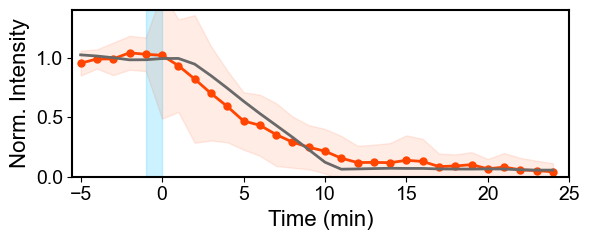


Optimizing HT elongation rate for UTag_C_Free
cells=24, responding=22; fixed ki=0.030000 1/s; seed=42; workers=-1
UTag_C_Free: best ke=3.000 aa/s; fixed ki=0.030000 1/s; cost=4.343073; mean |difference|=0.0401


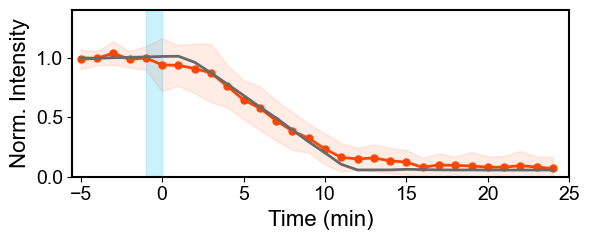


Optimizing HT elongation rate for SunTag
cells=33, responding=32; fixed ki=0.030000 1/s; seed=42; workers=-1
SunTag: best ke=4.500 aa/s; fixed ki=0.030000 1/s; cost=2.496272; mean |difference|=0.0599


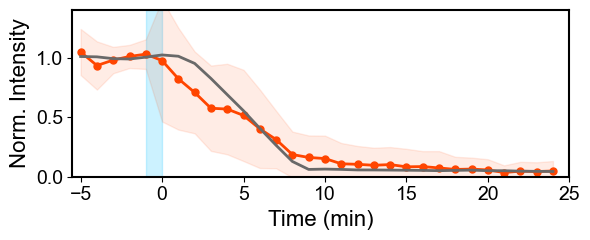


Optimizing HT elongation rate for AlfaTag
cells=32, responding=32; fixed ki=0.030000 1/s; seed=42; workers=-1
AlfaTag: best ke=3.300 aa/s; fixed ki=0.030000 1/s; cost=1.267693; mean |difference|=0.0415


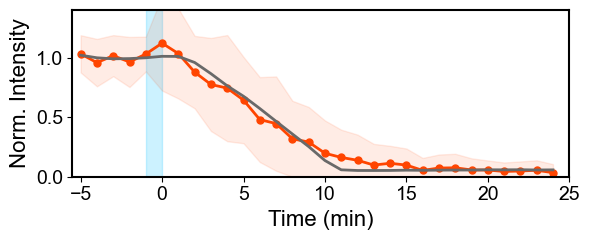

In [9]:
seed_all_rngs(REPRODUCIBLE_RANDOM_SEED)
list_datasets = ['utag', 'utag_c_free', 'suntag', 'alfatag']
optimization_results = {}

for dataset_name in list_datasets:
    result = evaluate_harringtonine_ke_optimization(dataset_name)
    if result:
        optimization_results[dataset_name] = result


In [10]:
def calculate_ht_grid_costs(mean_trajectory, sd_trajectory, model_bank):
    experimental_mean = np.asarray(mean_trajectory)[harringtonine_frame:max_frame]
    experimental_sd = np.asarray(sd_trajectory)[harringtonine_frame:max_frame]
    model_values = np.asarray(model_bank)[:, harringtonine_frame:max_frame]
    return np.sum(
        ((experimental_mean[None, :] - model_values) ** 2)
        / (experimental_sd[None, :] ** 2 + cost_epsilon),
        axis=1,
    )

def bootstrap_ht_fixed_grid(dataset, result, n_bootstrap=HT_BOOTSTRAP_REPLICATES):
    ke_grid = np.asarray(result['ke_grid'], dtype=float)
    model_bank = np.asarray(result['model_mean_trajectories'], dtype=float)
    trajectories = np.asarray(result['responding_trajectories'], dtype=float)
    rng = np.random.default_rng(stable_seed(REPRODUCIBLE_RANDOM_SEED, dataset, 'cell_bootstrap'))
    n_cells = trajectories.shape[0]
    records = []
    for bootstrap_replicate in range(1, n_bootstrap + 1):
        sample = trajectories[rng.integers(0, n_cells, size=n_cells)]
        costs = calculate_ht_grid_costs(sample.mean(axis=0), sample.std(axis=0), model_bank)
        best_index = int(np.argmin(costs))
        records.append({
            'dataset': dataset,
            'bootstrap_replicate': bootstrap_replicate,
            'n_responding_cells': n_cells,
            'ke_hat_aa_per_s': float(ke_grid[best_index]),
            'minimum_cost': float(costs[best_index]),
            'at_lower_grid_boundary': bool(best_index == 0),
            'at_upper_grid_boundary': bool(best_index == len(ke_grid) - 1),
        })
    return pd.DataFrame(records)

construct_labels = {
    'utag': 'Anti-UTag-IB',
    'utag_c_free': 'Anti-UTag-IB(ΔCys)',
    'suntag': 'Anti-SunTag-IB',
    'alfatag': 'Anti-ALFA-IB',
}
ht_summary_rows = []
ht_bootstrap_tables = []
for dataset in list_datasets:
    result = optimization_results[dataset]
    bootstrap_table = bootstrap_ht_fixed_grid(dataset, result)
    ht_bootstrap_tables.append(bootstrap_table)
    alpha = 1.0 - HT_BOOTSTRAP_INTERVAL_LEVEL
    interval_low, interval_high = np.quantile(
        bootstrap_table['ke_hat_aa_per_s'].to_numpy(),
        [alpha / 2.0, 1.0 - alpha / 2.0],
        method='nearest',
    )
    bootstrap_mode = float(
        bootstrap_table['ke_hat_aa_per_s'].value_counts().sort_index().idxmax()
    )
    lower_boundary_fraction = float(bootstrap_table['at_lower_grid_boundary'].mean())
    upper_boundary_fraction = float(bootstrap_table['at_upper_grid_boundary'].mean())
    ke_grid = np.asarray(result['ke_grid'], dtype=float)
    ht_summary_rows.append({
        'dataset': dataset,
        'construct': construct_labels[dataset],
        'ke_optimized_aa_per_s': float(result['best_ke']),
        'bootstrap_interval_level': HT_BOOTSTRAP_INTERVAL_LEVEL,
        'bootstrap_range_low_aa_per_s': float(interval_low),
        'bootstrap_range_high_aa_per_s': float(interval_high),
        'bootstrap_mode_aa_per_s': bootstrap_mode,
        'n_bootstrap_replicates': HT_BOOTSTRAP_REPLICATES,
        'n_total_cells': int(result['total_cells']),
        'n_responding_cells': int(result['responding_cells']),
        'ke_grid_min_aa_per_s': float(ke_grid.min()),
        'ke_grid_max_aa_per_s': float(ke_grid.max()),
        'ke_grid_step_aa_per_s': float(ke_grid[1] - ke_grid[0]),
        'fixed_ki_per_s': float(result['fixed_ki']),
        'drug_entry_delay_seconds': int(result['drug_entry_delay_seconds']),
        'inhibition_effectiveness_percent': float(result['inhibition_effectiveness_percent']),
        'bootstrap_lower_grid_boundary_fraction': lower_boundary_fraction,
        'bootstrap_upper_grid_boundary_fraction': upper_boundary_fraction,
        'response_threshold_fraction': float(result['response_threshold']),
        'n_model_repetitions_per_ke': int(result['n_model_repetitions']),
        'master_random_seed': REPRODUCIBLE_RANDOM_SEED,
        'interval_definition': '5th–95th percentiles of fixed-grid cell-bootstrap estimates (nearest observed order statistics)',
        'conditional_on': f'responding-cell selection, fixed ki, model bank, and {ke_grid_step:g}-aa/s ke grid',
    })

ht_summary_df = pd.DataFrame(ht_summary_rows)
ht_bootstrap_df = pd.concat(ht_bootstrap_tables, ignore_index=True)
ht_summary_path = optimization_tables_folder / 'ht_ke_optimization_with_90pct_bootstrap_ranges.csv'
ht_replicates_path = optimization_tables_folder / 'ht_ke_bootstrap_replicates.csv'
ht_summary_df.to_csv(ht_summary_path, index=False)
ht_bootstrap_df.to_csv(ht_replicates_path, index=False)

# Reproduce the ACF point estimates and optimization-solution ranges from
# optimization/plotting_optimization.ipynb for a self-contained table export.
acf_result_files = {
    'utag': 'results_df_utag.csv',
    'utag_c_free': 'results_df_utag_c_free.csv',
    'suntag': 'results_df_suntag.csv',
    'alfatag': 'results_df_alfatag.csv',
}

def round_to_four_significant_digits(value):
    return float(f'{value:.4g}')

acf_summary_rows = []
for dataset in list_datasets:
    acf_grid = pd.read_csv(acf_results_folder / acf_result_files[dataset]).copy()
    acf_grid['ki'] = acf_grid['ki'].apply(round_to_four_significant_digits)
    acf_grid['ke'] = acf_grid['ke'].apply(round_to_four_significant_digits)
    valid = acf_grid[np.isfinite(acf_grid['cost']) & (acf_grid['cost'] < 1e9)].copy()
    n_top = max(1, int(len(valid) * 0.05))
    top_solutions = valid.nsmallest(n_top, 'cost')
    acf_low, acf_high = np.percentile(top_solutions['ke'], [5.0, 95.0])
    acf_summary_rows.append({
        'dataset': dataset,
        'construct': construct_labels[dataset],
        'ke_optimized_aa_per_s': float(np.median(top_solutions['ke'])),
        'optimization_solution_range_level': 0.90,
        'optimization_range_low_aa_per_s': float(acf_low),
        'optimization_range_high_aa_per_s': float(acf_high),
        'n_valid_grid_solutions': int(len(valid)),
        'n_top_grid_solutions': int(n_top),
        'range_definition': '5th–95th percentiles of ke among the lowest-cost 5% of the ACF optimization grid; not a sampling confidence interval',
    })

acf_summary_df = pd.DataFrame(acf_summary_rows)
acf_value_columns = [
    'ke_optimized_aa_per_s',
    'optimization_range_low_aa_per_s',
    'optimization_range_high_aa_per_s',
]
acf_summary_df[acf_value_columns] = acf_summary_df[acf_value_columns].round(6)
acf_summary_path = optimization_tables_folder / 'acf_ke_optimization_with_90pct_solution_ranges.csv'
acf_summary_df.to_csv(acf_summary_path, index=False)

comparison_df = acf_summary_df[[
    'dataset', 'construct', 'ke_optimized_aa_per_s',
    'optimization_range_low_aa_per_s', 'optimization_range_high_aa_per_s',
]].rename(columns={
    'ke_optimized_aa_per_s': 'acf_ke_aa_per_s',
    'optimization_range_low_aa_per_s': 'acf_range_low_aa_per_s',
    'optimization_range_high_aa_per_s': 'acf_range_high_aa_per_s',
}).merge(
    ht_summary_df[[
        'dataset', 'ke_optimized_aa_per_s',
        'bootstrap_range_low_aa_per_s', 'bootstrap_range_high_aa_per_s',
        'n_total_cells', 'n_responding_cells',
    ]].rename(columns={
        'ke_optimized_aa_per_s': 'ht_ke_aa_per_s',
        'bootstrap_range_low_aa_per_s': 'ht_range_low_aa_per_s',
        'bootstrap_range_high_aa_per_s': 'ht_range_high_aa_per_s',
    }),
    on='dataset',
    how='inner',
    validate='one_to_one',
)
comparison_path = optimization_tables_folder / 'elongation_rate_comparison_ACF_HT.csv'
comparison_df.to_csv(comparison_path, index=False)

print('HT fixed-grid bootstrap ranges')
display(ht_summary_df[[
    'construct', 'ke_optimized_aa_per_s',
    'bootstrap_range_low_aa_per_s', 'bootstrap_range_high_aa_per_s',
    'n_responding_cells', 'n_total_cells',
]])
print('ACF–HT table values')
display(comparison_df)
print(f'\nSaved: {ht_summary_path}')
print(f'Saved: {ht_replicates_path}')
print(f'Saved: {acf_summary_path}')
print(f'Saved: {comparison_path}')


HT fixed-grid bootstrap ranges


,construct,ke_optimized_aa_per_s,bootstrap_range_low_aa_per_s,bootstrap_range_high_aa_per_s,n_responding_cells,n_total_cells
0,Anti-UTag-IB,3.3,3.3,4.5,32,38
1,Anti-UTag-IB(ΔCys),3.0,2.9,3.0,22,24
2,Anti-SunTag-IB,4.5,3.8,5.6,32,33
3,Anti-ALFA-IB,3.3,2.6,3.8,32,32


ACF–HT table values


,dataset,construct,acf_ke_aa_per_s,acf_range_low_aa_per_s,acf_range_high_aa_per_s,ht_ke_aa_per_s,ht_range_low_aa_per_s,ht_range_high_aa_per_s,n_total_cells,n_responding_cells
0,utag,Anti-UTag-IB,3.1140,2.101,4.63805,3.3,3.3,4.5,38,32
1,utag_c_free,Anti-UTag-IB(ΔCys),5.2915,4.127,6.55700,3.0,2.9,3.0,24,22
2,suntag,Anti-SunTag-IB,4.3290,3.013,5.94900,4.5,3.8,5.6,33,32
3,alfatag,Anti-ALFA-IB,4.8350,3.823,5.85305,3.3,2.6,3.8,32,32



Saved: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_7/optimization_tables/ht_ke_optimization_with_90pct_bootstrap_ranges.csv
Saved: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_7/optimization_tables/ht_ke_bootstrap_replicates.csv
Saved: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_7/optimization_tables/acf_ke_optimization_with_90pct_solution_ranges.csv
Saved: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_7/optimization_tables/elongation_rate_comparison_ACF_HT.csv
